In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [32]:
df = pd.read_excel("data/IV_40.xlsx")

y = df["Y"].values
x = df["X1"].values
z = df["Z1"].values
n = len(y)

In [33]:
df

,Y,X1,Z1
0,-2.522954,-5.143265,0
1,-6.510020,-7.265963,0
2,-2.675980,-5.279740,0
3,-2.088578,-4.693511,0
4,9.311424,9.319498,0
...,...,...,...
1495,-0.926497,0.605483,1
1496,1.169525,3.387240,1
1497,-0.360283,1.966911,1
1498,3.594734,6.008488,1


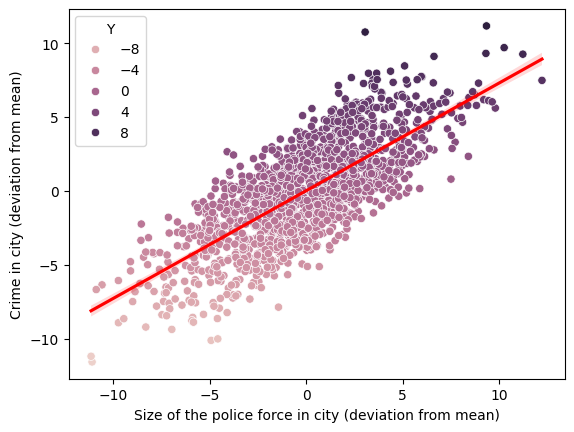

In [34]:
ax = sns.scatterplot(data=df, x="X1", y="Y", hue="Y")

sns.regplot(
    data=df,
    x="X1",
    y="Y",
    scatter=False,
    ax=ax,
    color="red"
)

plt.xlabel("Size of the police force in city (deviation from mean)")
plt.ylabel("Crime in city (deviation from mean)")

plt.show()

## 2.a

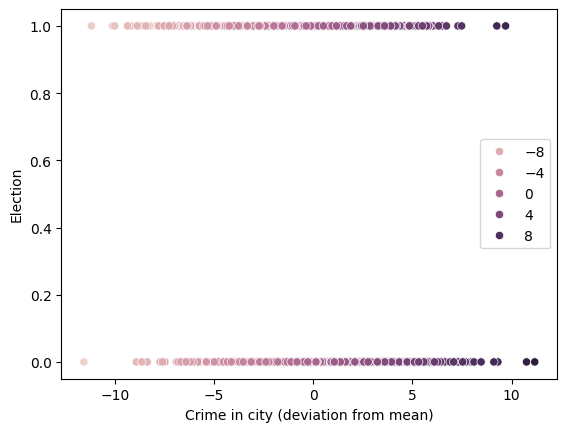

In [35]:
ax = sns.scatterplot(data=df, x="Y", y="Z1", hue="Y")
plt.xlabel("Crime in city (deviation from mean)")
plt.ylabel("Election")
ax.legend(loc="center right")
plt.show()

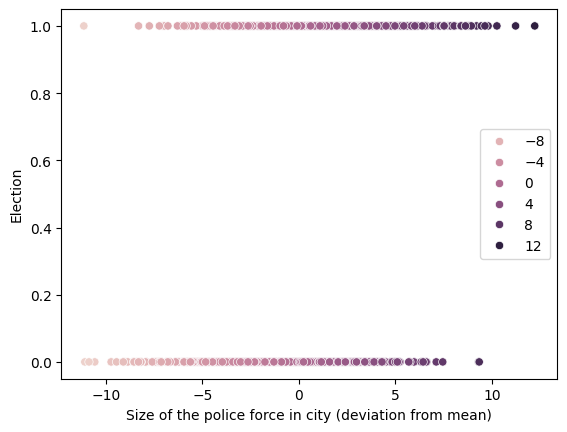

In [36]:
ax = sns.scatterplot(data=df, x="X1", y="Z1", hue="X1")
plt.xlabel("Size of the police force in city (deviation from mean)")
plt.ylabel("Election")
ax.legend(loc="center right")
plt.show()

## 2.b

In [39]:
Z_mat = sm.add_constant(z)  # adds intercept
model = sm.OLS(x, Z_mat).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                     172.2
Date:                Sat, 18 Apr 2026   Prob (F-statistic):           2.55e-37
Time:                        18:09:38   Log-Likelihood:                -3893.0
No. Observations:                1500   AIC:                             7790.
Df Residuals:                    1498   BIC:                             7801.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.2050      0.118    -10.170      0.0

## 2.c

In [47]:
pi0 = model.params[0]
pi1 = model.params[1]
v = x - pi0 - pi1 * z

In [49]:
X_mat = sm.add_constant(np.column_stack((x, v)))  # adds intercept
model = sm.OLS(y, X_mat).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     3740.
Date:                Sat, 18 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:52:24   Log-Likelihood:                -2608.0
No. Observations:                1500   AIC:                             5222.
Df Residuals:                    1497   BIC:                             5238.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1512      0.036     -4.229      0.0